In [7]:
# Cellule d'import : On importe tout ici dans cette cellule pour garder le notebook propre.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration visuelle globale
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Chargement du dataset
# Le fichier est placé dans le dossier data/ à la racine du projet
df = pd.read_csv("data/etrilabs_sante_maternelle_pf.csv")

# Premier regard sur les données : dimensions et premières lignes
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dataset chargé : 1200 lignes, 16 colonnes


,id_enquete,pays,region_departement,milieu,age_annees,niveau_instruction,langue_principale,distance_centre_sante_km,nb_consultations_prenatales,utilisation_contraceptif_moderne,accouchement_assiste_professionnel,nb_enfants_vivants,revenu_mensuel_menage_fcfa,connaissance_service_pf,visite_agent_sante_communautaire_6mois,satisfaction_service_sante_1a5
0,ENQ-0001,Bénin,Borgou,Péri-urbain,45,Primaire,Yoruba,0.6,1.0,0.0,0,1,115353.0,0,0,5
1,ENQ-0002,Sénégal,Dakar,Urbain,41,Secondaire,Wolof,1.3,3.0,0.0,1,0,53817.0,1,1,1
2,ENQ-0003,Sénégal,Kolda,Rural,25,Secondaire,Autre,18.4,3.0,1.0,1,4,18436.0,1,0,5
3,ENQ-0004,Sénégal,Saint-Louis,Rural,19,Aucun,Autre,10.5,2.0,0.0,1,4,NaN,1,0,2
4,ENQ-0005,Bénin,Mono,Rural,22,Aucun,Fon,1.0,1.0,0.0,0,4,21156.0,1,0,4


#### 1. Chargement des données

Le dataset porte sur la santé maternelle en Afrique de l'Ouest. Il contient des informations
sur le profil socio-démographique des femmes, leur accès aux soins, et leurs comportements
de santé reproductive. Notre variable cible pour la modélisation sera
`accouchement_assiste_professionnel` — un indicateur binaire (0/1) qui traduit directement
le risque d'accouchement sans assistance médicale.

In [3]:
#on prend le temps de bien comprendre ce qu'on a; les valeurs manquantes, et les distributions des variables clés. 
print("=== Informations générales ===")
print(df.info())

print("\n=== Valeurs manquantes par colonne ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante détectée")

print("\n=== Statistiques descriptives (variables numériques) ===")
df.describe().round(2)

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id_enquete                              1200 non-null   object 
 1   pays                                    1200 non-null   object 
 2   region_departement                      1200 non-null   object 
 3   milieu                                  1200 non-null   object 
 4   age_annees                              1200 non-null   int64  
 5   niveau_instruction                      1200 non-null   object 
 6   langue_principale                       1200 non-null   object 
 7   distance_centre_sante_km                1117 non-null   float64
 8   nb_consultations_prenatales             1116 non-null   float64
 9   utilisation_contraceptif_moderne        1134 non-null   float64
 10  accouchement_assiste_professi

,age_annees,distance_centre_sante_km,nb_consultations_prenatales,utilisation_contraceptif_moderne,accouchement_assiste_professionnel,nb_enfants_vivants,revenu_mensuel_menage_fcfa,connaissance_service_pf,visite_agent_sante_communautaire_6mois,satisfaction_service_sante_1a5
count,1200.00,1117.00,1116.00,1134.00,1200.00,1200.00,1047.00,1200.00,1200.00,1200.00
mean,32.08,8.39,2.20,0.30,0.60,3.60,121528.93,0.56,0.43,3.84
std,10.03,10.40,1.72,0.46,0.49,2.02,398519.03,0.50,0.50,7.38
min,15.00,0.50,0.00,0.00,0.00,0.00,3566.00,0.00,0.00,1.00
25%,24.00,1.60,1.00,0.00,0.00,2.00,30044.00,0.00,0.00,2.00
50%,32.00,4.20,2.00,0.00,1.00,3.00,56846.00,1.00,0.00,3.00
75%,41.00,11.40,3.00,1.00,1.00,5.00,117159.50,1.00,1.00,4.00
max,49.00,80.00,8.00,1.00,1.00,11.00,6744311.00,1.00,1.00,99.00


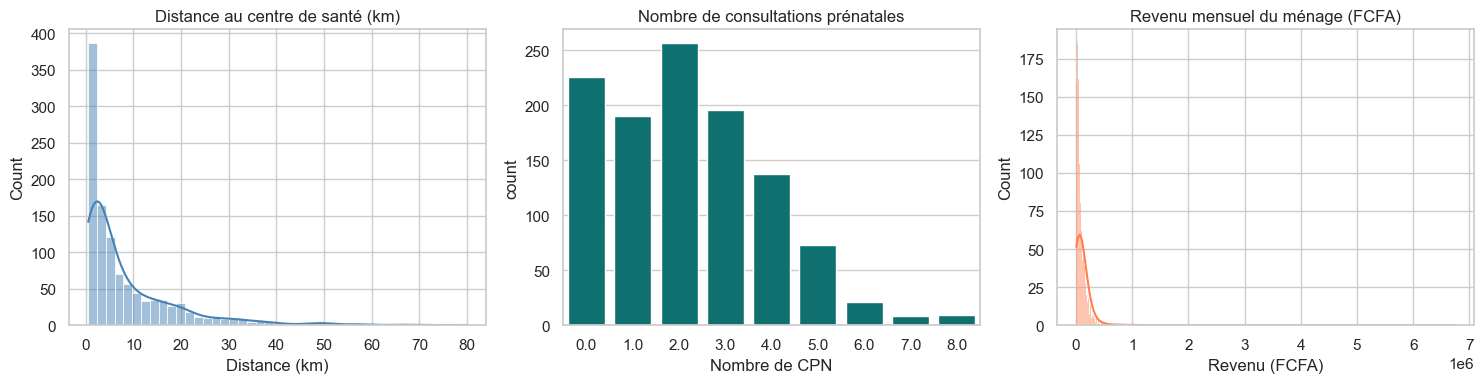


=== Répartition de la variable cible ===
accouchement_assiste_professionnel
1    60.0
0    40.0
Name: proportion, dtype: float64


In [5]:
# On visualise les variables les plus importantes pour notre problématique :
# la distance au centre de santé, le nombre de CPN, et le revenu du ménage.
# Ces trois variables sont au coeur de nos hypothèses terrain.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la distance au centre de santé
sns.histplot(df['distance_centre_sante_km'], ax=axes[0], color='steelblue', kde=True)
axes[0].set_title("Distance au centre de santé (km)")
axes[0].set_xlabel("Distance (km)")

# Distribution du nombre de consultations prénatales
sns.countplot(x='nb_consultations_prenatales', data=df, ax=axes[1], color='teal')
axes[1].set_title("Nombre de consultations prénatales")
axes[1].set_xlabel("Nombre de CPN")

# Distribution du revenu mensuel du ménage
sns.histplot(df['revenu_mensuel_menage_fcfa'], ax=axes[2], color='coral', kde=True)
axes[2].set_title("Revenu mensuel du ménage (FCFA)")
axes[2].set_xlabel("Revenu (FCFA)")

plt.tight_layout()
plt.savefig("figures/distributions_cles.png", dpi=150)
plt.show()

# Distribution de notre variable cible
print("\n=== Répartition de la variable cible ===")
print(df['accouchement_assiste_professionnel'].value_counts(normalize=True).round(3) * 100)

#### 2b. Distributions des variables clés

Le dataset contient **1200 observations** et **16 variables**. Quelques points importants
avant d'aller plus loin :

**Valeurs manquantes à noter :**
- `distance_centre_sante_km` : 83 valeurs manquantes (6.9%)
- `nb_consultations_prenatales` : 84 valeurs manquantes (7%)
- `revenu_mensuel_menage_fcfa` : 153 valeurs manquantes (12.75%), la plus affectée
- Ces valeurs manquantes ne sont probablement pas aléatoires : ce sont souvent
  les femmes les plus précaires qui n'ont pas déclaré leur revenu. On en tiendra
  compte lors du preprocessing.

**Sur les distributions observées :**
- La distance est fortement asymétrique majorité des femmes à moins de 5km,
  mais une queue jusqu'à 80km. Une transformation logarithmique sera appliquée.
- Le nombre de CPN est préoccupant : beaucoup de femmes à 0 ou 1 consultation,
  loin du seuil recommandé de 4 par l'OMS.
- Le revenu est extrêmement concentré vers les faibles valeurs transformation
  logarithmique également nécessaire.

**Variable cible :** 60% des accouchements sont assistés par un professionnel,
40% ne le sont pas. Le dataset est relativement équilibré pas besoin de
rééchantillonnage, mais on restera attentif aux métriques au-delà de la simple accuracy.

=== Hypothèse 1 ===
Lignes utilisées après suppression des NaN : 1041
Corrélation de Spearman : -0.199
P-value : 0.0000
Conclusion : Corrélation significative


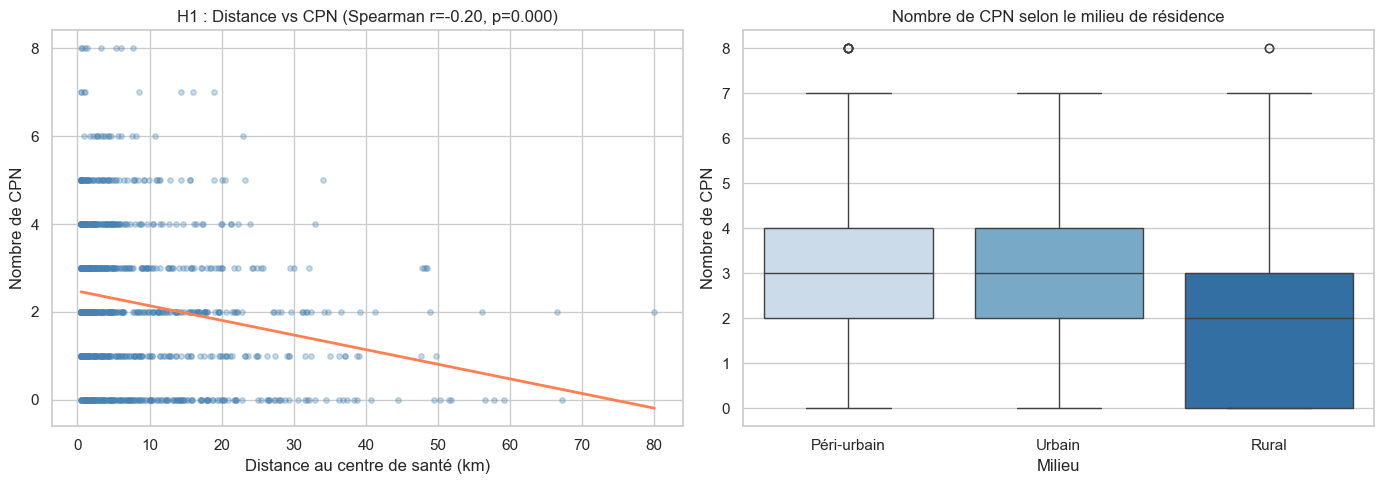

In [ ]:
# --- HYPOTHÈSE ---

# On teste notre première hypothèse : plus une femme est éloignée d'un centre

# Suppression des lignes avec valeurs manquantes pour les variables concernées
df_h1 = df[['distance_centre_sante_km',
             'nb_consultations_prenatales',
             'milieu']].dropna()

# Test de corrélation de Spearman
corr, pvalue = stats.spearmanr(
    df_h1['distance_centre_sante_km'],
    df_h1['nb_consultations_prenatales']
)

print("=== Hypothèse 1 ===")
print(f"Lignes utilisées après suppression des NaN : {len(df_h1)}")
print(f"Corrélation de Spearman : {corr:.3f}")
print(f"P-value : {pvalue:.4f}")
print(f"Conclusion : {'Corrélation significative' if pvalue < 0.05 else 'Pas de corrélation significative'}")

# Visualisation H1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot avec ligne de tendance
axes[0].scatter(df_h1['distance_centre_sante_km'],
                df_h1['nb_consultations_prenatales'],
                alpha=0.3, color='steelblue', s=15)

# Ligne de tendance sur données nettoyées
z = np.polyfit(df_h1['distance_centre_sante_km'],
               df_h1['nb_consultations_prenatales'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_h1['distance_centre_sante_km'].min(),
                     df_h1['distance_centre_sante_km'].max(), 100)
axes[0].plot(x_line, p_line(x_line), color='coral', linewidth=2)
axes[0].set_xlabel("Distance au centre de santé (km)")
axes[0].set_ylabel("Nombre de CPN")
axes[0].set_title(f"H1 : Distance vs CPN (Spearman r={corr:.2f}, p={pvalue:.3f})")

# Boxplot : CPN selon le milieu de résidence
sns.boxplot(x='milieu', y='nb_consultations_prenatales',
            data=df_h1, ax=axes[1], palette='Blues')
axes[1].set_title("Nombre de CPN selon le milieu de résidence")
axes[1].set_xlabel("Milieu")
axes[1].set_ylabel("Nombre de CPN")

plt.tight_layout()
plt.savefig("figures/hypothese1.png", dpi=150)
plt.show()

#### 3a. Hypothèse 1 :Distance et consultations prénatales

**Résultat :** Corrélation de Spearman r = -0.20, p < 0.0001 (n=1041 observations)

H1 est **confirmée** : il existe une corrélation négative significative entre la distance
au centre de santé et le nombre de CPN effectuées. Plus une femme est éloignée,
moins elle consulte.

La corrélation est modérée (-0.20) ce qui est attendu : la distance n'est pas le seul
facteur, mais elle joue un rôle statistiquement démontrable.

Le boxplot par milieu renforce ce résultat : les femmes rurales ont une médiane de CPN
inférieure à celles des milieux urbain et péri-urbain, avec une dispersion plus large
signe d'une forte hétérogénéité au sein même du milieu rural.

**Interprétation terrain :** Ce résultat valide la distance comme variable clé dans notre
modèle de scoring de risque. Une femme à plus de 15-20km d'un centre de santé présente
un profil de sous-suivi prénatal significativement plus élevé c'est exactement le signal
que les ASC doivent pouvoir détecter en amont.

=== Hypothèse 2 — Table de contingence ===
accouchement_assiste_professionnel        0    1   All
visite_agent_sante_communautaire_6mois                
0                                       307  375   682
1                                       173  345   518
All                                     480  720  1200

Chi² : 16.074 | P-value : 0.0001
Conclusion : Association significative


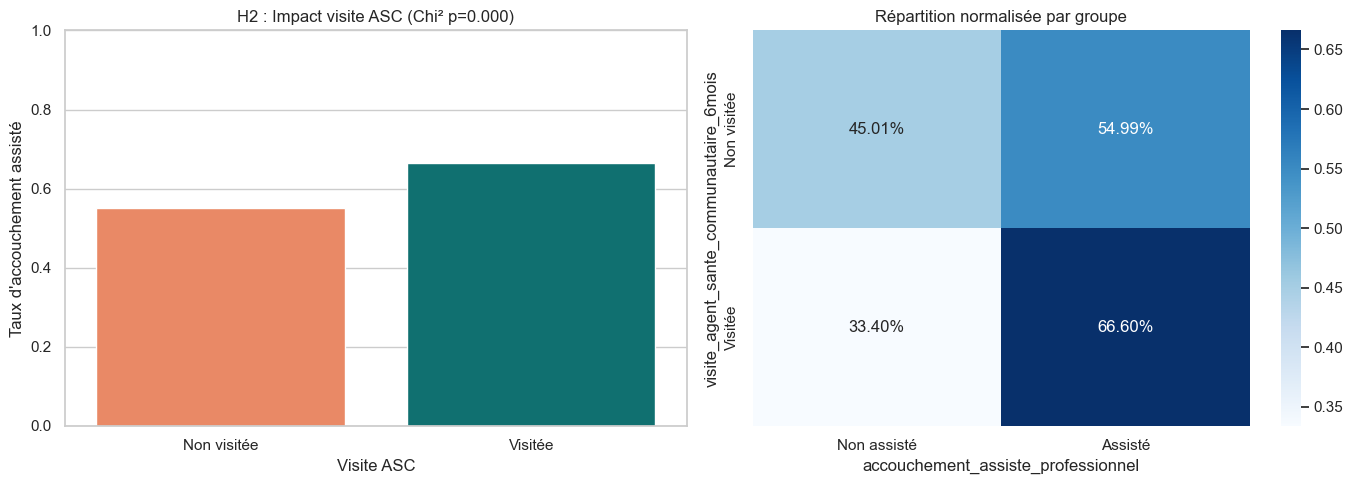

In [11]:
# --- HYPOTHÈSE 2 ---
# Les femmes visitées par un ASC accouchent-elles plus souvent
# avec un professionnel de santé ?

from scipy.stats import chi2_contingency

# Table de contingence
contingency = pd.crosstab(
    df['visite_agent_sante_communautaire_6mois'],
    df['accouchement_assiste_professionnel'],
    margins=True
)
print("=== Hypothèse 2 — Table de contingence ===")
print(contingency)

chi2, p, dof, expected = chi2_contingency(
    pd.crosstab(df['visite_agent_sante_communautaire_6mois'],
                df['accouchement_assiste_professionnel'])
)
print(f"\nChi² : {chi2:.3f} | P-value : {p:.4f}")
print(f"Conclusion : {'Association significative' if p < 0.05 else 'Pas d association significative'}")

# Visualisation H2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux d'accouchement assisté selon visite ASC
taux = df.groupby('visite_agent_sante_communautaire_6mois')[
    'accouchement_assiste_professionnel'].mean().reset_index()
taux.columns = ['Visite ASC', 'Taux accouchement assisté']
taux['Visite ASC'] = taux['Visite ASC'].map({0: 'Non visitée', 1: 'Visitée'})

sns.barplot(x='Visite ASC', y='Taux accouchement assisté',
            data=taux, ax=axes[0], palette=['coral', 'teal'])
axes[0].set_title(f"H2 : Impact visite ASC (Chi² p={p:.3f})")
axes[0].set_ylabel("Taux d'accouchement assisté")
axes[0].set_ylim(0, 1)

# Heatmap de la table de contingence normalisée
sns.heatmap(
    pd.crosstab(df['visite_agent_sante_communautaire_6mois'],
                df['accouchement_assiste_professionnel'],
                normalize='index'),
    annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
    xticklabels=['Non assisté', 'Assisté'],
    yticklabels=['Non visitée', 'Visitée']
)
axes[1].set_title("Répartition normalisée par groupe")

plt.tight_layout()
plt.savefig("figures/hypothese2.png", dpi=150)
plt.show()

#### 3b. Hypothèse 2 : Impact des visites ASC sur l'accouchement assisté

**Résultat :** Chi² = 16.07, p < 0.0001

H2 est **confirmée** : la visite d'un ASC dans les 6 derniers mois est significativement
associée à un accouchement assisté par un professionnel de santé.

Les chiffres sont parlants : parmi les femmes visitées par un ASC, 66.6% ont accouché
avec assistance contre seulement 55% pour celles qui ne l'ont pas été. Une différence
de 11.6 points de pourcentage, statistiquement solide.

**Interprétation terrain :** Ce résultat est le plus important pour notre solution.
Il valide empiriquement le levier d'action central de notre approche : si on arrive à
diriger les visites ASC vers les femmes les plus à risque plutôt qu'en couverture
uniforme du territoire, on peut augmenter significativement le taux d'accouchement
assisté. C'est exactement ce que le modèle de scoring est conçu à faire.

**Nuance importante :** L'association est significative mais pas suffisante pour conclure
à une causalité. Les femmes visitées par un ASC sont peut-être aussi celles qui vivent
plus près d'un centre de santé ou qui ont un meilleur niveau d'instruction. La cellule
de modélisation permettra de contrôler ces effets simultanément.

In [13]:
# Avant entraînement du modele : gérer les valeurs manquantes, encoder les variables catégorielles, et séparer les features de la variable cible.
# On va aussi garde uniquement les variables pertinentes pour notre problématique.

# --- SÉLECTION DES FEATURES ---
features = [
    'distance_centre_sante_km',
    'nb_consultations_prenatales',
    'revenu_mensuel_menage_fcfa',
    'niveau_instruction',
    'milieu',
    'visite_agent_sante_communautaire_6mois',
    'connaissance_service_pf',
    'nb_enfants_vivants',
    'age_annees'
]

target = 'accouchement_assiste_professionnel'

df_model = df[features + [target]].copy()

print(f"Taille avant nettoyage : {df_model.shape}")

# --- GESTION DES VALEURS MANQUANTES ---
# Pour les variables numériques : imputation par la médiane
# (plus robuste que la moyenne face aux distributions asymétriques)
num_cols = ['distance_centre_sante_km',
            'nb_consultations_prenatales',
            'revenu_mensuel_menage_fcfa']

for col in num_cols:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)
    print(f"{col} : NaN remplacés par médiane = {median_val:.1f}")

print(f"\nValeurs manquantes restantes : {df_model.isnull().sum().sum()}")

# --- ENCODAGE DES VARIABLES CATÉGORIELLES ---
# On utilise get_dummies pour éviter l'ordinalité artificielle
# que LabelEncoder introduirait sur des variables nominales
df_model = pd.get_dummies(df_model,
                           columns=['niveau_instruction', 'milieu'],
                           drop_first=True)

print(f"\nTaille après encodage : {df_model.shape}")
print(f"Colonnes finales : {list(df_model.columns)}")

# --- SÉPARATION FEATURES / CIBLE ---
X = df_model.drop(columns=[target])
y = df_model[target]

# --- SPLIT TRAIN / TEST (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Répartition cible train : {y_train.mean():.2%} assistés")
print(f"Répartition cible test  : {y_test.mean():.2%} assistés")

Taille avant nettoyage : (1200, 10)
distance_centre_sante_km : NaN remplacés par médiane = 4.2
nb_consultations_prenatales : NaN remplacés par médiane = 2.0
revenu_mensuel_menage_fcfa : NaN remplacés par médiane = 56846.0

Valeurs manquantes restantes : 0

Taille après encodage : (1200, 13)
Colonnes finales : ['distance_centre_sante_km', 'nb_consultations_prenatales', 'revenu_mensuel_menage_fcfa', 'visite_agent_sante_communautaire_6mois', 'connaissance_service_pf', 'nb_enfants_vivants', 'age_annees', 'accouchement_assiste_professionnel', 'niveau_instruction_Primaire', 'niveau_instruction_Secondaire', 'niveau_instruction_Supérieur', 'milieu_Rural', 'milieu_Urbain']

Train : 960 lignes | Test : 240 lignes
Répartition cible train : 60.00% assistés
Répartition cible test  : 60.00% assistés


#### 4. Preprocessing et préparation des données

Les données sont prêtes pour la modélisation :

**Valeurs manquantes** imputées par la médiane :
- Distance : 4.2 km
- CPN : 2.0 consultations (confirme le sous-suivi observé en cellule 2b)
- Revenu : 56 846 FCFA/mois (~86€, cohérent avec les revenus en zone rurale sénégalaise)

**Encodage** : les variables `niveau_instruction` et `milieu` ont été transformées
en variables binaires (dummy encoding). On passe de 10 à 13 colonnes.

**Split train/test** : 960 lignes pour l'entraînement, 240 pour l'évaluation.
La stratification garantit un équilibre parfait de la variable cible dans les deux
ensembles (60% assistés / 40% non assistés) les résultats d'évaluation seront
représentatifs de la distribution réelle.